# **Preprocessing**
dataset: dataset_gizi_terupdate.csv

In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer, StandardScaler
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib

In [19]:
# 1. LOAD DATA & STANDARISASI TEKS
print("--- MEMUAT DATASET ---")
df = pd.read_csv('data/dataset_gizi_terupdate.csv')
print(f"Data awal: {df.shape[0]} baris")

# Memperbaiki ukuran porsi yang hanya berisi angka murni menjadi format gram ('... g')
if 'Ukuran Porsi' in df.columns:
    # Regex ini mendeteksi jika string HANYA berisi angka (contoh: '100' atau '50.0') lalu menambahkan ' g'
    df['Ukuran Porsi'] = df['Ukuran Porsi'].astype(str).replace(r'^(\d+(?:\.\d+)?)$', r'\1 g', regex=True)
    print("Standarisasi format Ukuran Porsi selesai.")

# Membuat kolom sementara (huruf kecil dan tanpa spasi berlebih) untuk pencocokan regex
df['Nama Makanan Clean'] = df['Nama Makanan'].astype(str).str.lower().str.strip()

--- MEMUAT DATASET ---
Data awal: 3183 baris
Standarisasi format Ukuran Porsi selesai.


In [20]:
# 2. FILTERING (BLACKLIST MINUMAN, MENTAH, & NOISE)
print("\n--- MEMBERSIHKAN DATASET ---")
minuman_keywords = [
    r'\bair\b', r'\bes\b', r'\bteh\b', r'\bkopi\b', r'\bjus\b', r'\bsusu\b', r'\bsirup\b', r'\bminuman\b',
    r'\bcoffee\b', r'\btea\b', r'\bice\b', r'\bjuice\b', r'\bmilk\b', r'\bsyrup\b', r'\bdrink\b', r'\bwater\b',
    r'\blatte\b', r'\bmojito\b', r'\bwhiskey\b', r'\bsoda\b', r'\bcola\b', r'\bale\b', r'\bwine\b', r'\bbeer\b', r'\bbir\b',
    r'\bboba\b', r'\bmilkshake\b', r'\bsmoothie\b', r'\byogurt\b', r'\byoghurt\b', r'\bmacha\b', r'\bmatcha\b',
    r'\bamericano\b', r'\bcappuccino\b', r'\bespresso\b', r'\bmacchiato\b', r'\bfrappe\b', r'\byakult\b', r'\bsprite\b',
    r'\bfanta\b', r'\bcincau\b', r'\bdawet\b', r'\bcendol\b', r'\bwedang\b', r'\bbandrek\b', r'\bbajigur\b',
    r'\bsquash\b', r'\bshake\b', r'\barak\b', r'\btuak\b', r'\bsoju\b'
]

bahan_mentah_keywords = [
    r'\bminyak\b', r'\boil\b', r'\broyco\b', r'\bmasako\b', r'\btotole\b', r'\bsasa\b', r'\bajinomoto\b', r'\bmicin\b',
    r'\bmsg\b', r'\bbumbu\b', r'\bpenyedap\b', r'\bsaus\b', r'\bsaos\b', r'\bkecap\b', r'\bcuka\b', r'\btepung\b',
    r'\bgula\b', r'\bgaram\b', r'\bkaldu\b', r'\bmargarin\b', r'\bmentega\b', r'\bbutter\b', r'\bmayonnaise\b',
    r'\bmayones\b', r'\bsantan\b', r'\bsambal\b', r'\bsambel\b', r'\bterasi\b', r'\bpetis\b', r'\blada\b', r'\bmerica\b',
    r'\bketumbar\b', r'\bkemiri\b', r'\bvanili\b', r'\bvanilla\b', r'\bragi\b', r'\byeast\b', r'\bberas\b', r'\brice\b',
    r'\bmentah\b', r'\bbaking powder\b', r'\bbaking soda\b'
]

noise_keywords = [
    r'\bready to go\b', r'\bbutir\b', r'\bdimasak\b', r'\byc\b', r'\byummy\b', r'\bceker\b', r'\bpala\b',
    r'\bsachet\b', r'\bkemasan\b', r'\bbotol\b', r'\bkaleng\b', r'\bbungkus\b', r'\bcup\b', r'\bpiring\b',
    r'\bmangkok\b', r'\bsendok\b', r'\binstan\b', r'\binstant\b', r'\bbubuk\b', r'\bserbuk\b', r'\bmentahan\b'
]

blacklist = minuman_keywords + bahan_mentah_keywords + noise_keywords
regex_pattern = '|'.join(blacklist)

# 2A. Filter berdasarkan Nama Makanan (Blacklist Regex)
df_bersih = df[~df['Nama Makanan Clean'].str.contains(regex_pattern, regex=True, na=False)].copy()

# 2B. Filter berdasarkan Satuan Ukuran Porsi (Sapu bersih sisa minuman berdasar satuan cairan)
if 'Ukuran Porsi' in df_bersih.columns:
    # Mendeteksi baris yang ukuran porsinya mengandung 'ml', 'liter', atau 'cc'
    kondisi_minuman_satuan = df_bersih['Ukuran Porsi'].astype(str).str.lower().str.contains(r'\b(ml|liter|cc)\b', regex=True, na=False)
    baris_dihapus_satuan = kondisi_minuman_satuan.sum()
    # Membuang baris yang terdeteksi sebagai minuman
    df_bersih = df_bersih[~kondisi_minuman_satuan].copy()
    print(f"Filter tambahan: {baris_dihapus_satuan} sisa minuman dihapus berdasarkan satuan 'ml/liter'.")


--- MEMBERSIHKAN DATASET ---
Filter tambahan: 67 sisa minuman dihapus berdasarkan satuan 'ml/liter'.


C:\Users\Nazril Abi Widiasto\AppData\Local\Temp\ipykernel_17120\2514423122.py:37: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  kondisi_minuman_satuan = df_bersih['Ukuran Porsi'].astype(str).str.lower().str.contains(r'\b(ml|liter|cc)\b', regex=True, na=False)


In [21]:
# 3. PENANGANAN DUPLIKAT (PRIORITAS BAHASA INDONESIA)
df_bersih['Gizi_Hash'] = (
    df_bersih['Kalori (kkal)'].astype(str) + '_' +
    df_bersih['Karbohidrat (g)'].astype(str) + '_' +
    df_bersih['Lemak (g)'].astype(str)
)

english_words = r'\b(fried|chicken|beef|noodle|soup|pork|fish|grilled|steak|burger|cake|pie)\b'
df_bersih['is_english'] = df_bersih['Nama Makanan Clean'].str.contains(english_words, regex=True).astype(int)
df_bersih = df_bersih.sort_values(by='is_english')
df_bersih = df_bersih.drop_duplicates(subset=['Gizi_Hash'], keep='first').copy()
print(f"Data setelah menghapus blacklist dan duplikat: {df_bersih.shape[0]} baris")

Data setelah menghapus blacklist dan duplikat: 2181 baris


C:\Users\Nazril Abi Widiasto\AppData\Local\Temp\ipykernel_17120\3065682729.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_bersih['is_english'] = df_bersih['Nama Makanan Clean'].str.contains(english_words, regex=True).astype(int)


In [22]:
# 4. OUTLIER: DOMAIN-KNOWLEDGE & LOGICAL CONSISTENCY
print("\n--- FILTERING OUTLIER (DOMAIN KNOWLEDGE) ---")
kolom_numerik = ['Kalori (kkal)', 'Karbohidrat (g)', 'Lemak (g)', 'Protein (g)']
for col in kolom_numerik:
    df_bersih[col] = pd.to_numeric(df_bersih[col], errors='coerce')
df_bersih = df_bersih.dropna(subset=kolom_numerik)

# A. Hard Limits (Batas Fisika & Biologi)
kondisi_positif = (df_bersih[kolom_numerik] >= 0).all(axis=1)
kondisi_kalori_max = df_bersih['Kalori (kkal)'] <= 900
kondisi_makro_max = (df_bersih['Karbohidrat (g)'] + df_bersih['Lemak (g)'] + df_bersih['Protein (g)']) <= 100

df_bersih = df_bersih[kondisi_positif & kondisi_kalori_max & kondisi_makro_max].copy()

# B. Logical Consistency Check (Pengecekan Konsistensi Kalori)
kalori_hitung = (df_bersih['Karbohidrat (g)'] * 4) + (df_bersih['Protein (g)'] * 4) + (df_bersih['Lemak (g)'] * 9)
selisih_absolut = abs(df_bersih['Kalori (kkal)'] - kalori_hitung)
kalori_aman = df_bersih['Kalori (kkal)'].replace(0, 1e-5)
margin_error = selisih_absolut / kalori_aman

# Hapus baris yang memiliki margin error > 20% DAN selisih mutlak > 50 kkal
kondisi_logis = ~((margin_error > 0.20) & (selisih_absolut > 50))
df_bersih = df_bersih[kondisi_logis].copy()
print(f"Data setelah Pengecekan Domain Knowledge & Logika: {df_bersih.shape[0]} baris")


--- FILTERING OUTLIER (DOMAIN KNOWLEDGE) ---
Data setelah Pengecekan Domain Knowledge & Logika: 2117 baris


## **Feature Engineering**

In [23]:
# 5. FEATURE ENGINEERING (KATEGORI, ALERGI, DIET LABELS)
print("\n--- FEATURE ENGINEERING ---")
def tentukan_kategori(nama):
    if re.search(r'\b(bayam|kangkung|wortel|sawi|brokoli|kol|selada|sayur|tomat|buncis|terong|toge|tauge|capcay|daun|pare)\b', nama):
        return 'Sayur'
    elif re.search(r'\b(apel|pisang|jeruk|mangga|anggur|melon|semangka|pepaya|nanas|buah|alpukat|strawberry|berry|durian|kurma)\b', nama):
        return 'Buah'
    elif re.search(r'\b(kue|biskuit|keripik|cokelat|permen|snack|roti|pie|cake|cookie|chips|dessert|jelly|candy|gorengan|martabak|bakpia|puding|kacang|kerupuk)\b', nama):
        return 'Snack'
    elif re.search(r'\b(ayam|ikan|daging|sapi|kambing|telur|tahu|tempe|udang|cumi|sosis|nugget|lele|bandeng|teri|bebek|seafood)\b', nama):
        return 'Lauk'
    elif re.search(r'\b(nasi|mie|soto|bakso|sate|gulai|rendang|bubur|sup|lontong|ketoprak|pecel|pasta|spaghetti|burger|pizza|bihun|kwetiau)\b', nama):
        return 'Masakan'
    else:
        return 'Masakan'

df_bersih['Kategori'] = df_bersih['Nama Makanan Clean'].apply(tentukan_kategori)

# Alergi
df_bersih['is_seafood'] = df_bersih['Nama Makanan Clean'].str.contains(r'\b(ikan|udang|cumi|kerang|kepiting|seafood|tuna|salmon|tongkol|lele)\b', regex=True).astype(int)
df_bersih['is_peanut']  = df_bersih['Nama Makanan Clean'].str.contains(r'\b(kacang|peanut|almond|mete|mede)\b', regex=True).astype(int)
df_bersih['is_dairy']   = df_bersih['Nama Makanan Clean'].str.contains(r'\b(keju|krim|cheese)\b', regex=True).astype(int)

# Rasio dan Label Diet (Menggunakan data asli sebelum ditransformasi)
safe_kalori = df_bersih['Kalori (kkal)'].replace(0, 1e-5)
df_bersih['protein_to_calorie_ratio'] = df_bersih['Protein (g)'] / safe_kalori
df_bersih['is_low_calorie']  = (df_bersih['Kalori (kkal)'] <= 100).astype(int)
df_bersih['is_low_fat']      = (df_bersih['Lemak (g)'] <= 3).astype(int)
df_bersih['is_low_carb']     = (df_bersih['Karbohidrat (g)'] <= 10).astype(int)
df_bersih['is_high_carb']    = (((df_bersih['Karbohidrat (g)'] * 4) / safe_kalori) > 0.60).astype(int)
df_bersih['is_high_protein'] = (((df_bersih['Protein (g)'] * 4) / safe_kalori) > 0.20).astype(int)


--- FEATURE ENGINEERING ---


C:\Users\Nazril Abi Widiasto\AppData\Local\Temp\ipykernel_17120\2690311685.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_bersih['is_seafood'] = df_bersih['Nama Makanan Clean'].str.contains(r'\b(ikan|udang|cumi|kerang|kepiting|seafood|tuna|salmon|tongkol|lele)\b', regex=True).astype(int)
C:\Users\Nazril Abi Widiasto\AppData\Local\Temp\ipykernel_17120\2690311685.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_bersih['is_peanut']  = df_bersih['Nama Makanan Clean'].str.contains(r'\b(kacang|peanut|almond|mete|mede)\b', regex=True).astype(int)
C:\Users\Nazril Abi Widiasto\AppData\Local\Temp\ipykernel_17120\2690311685.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_bersih['is_dairy']   = df_bersih['Nama M

In [24]:
# 6. SKEWNESS TRANSFORMATION & SCALING (TERPADU)
print("\n--- TRANSFORMATION & SCALING ---")
# standardize=True otomatis melakukan standardisasi. Kita tidak perlu StandardScaler terpisah.
scaler_terpadu = PowerTransformer(method='yeo-johnson', standardize=True)

# Kolom sumber (data asli)
kolom_skala = ['Kalori (kkal)', 'Karbohidrat (g)', 'Lemak (g)', 'Protein (g)', 'protein_to_calorie_ratio']

# Kolom tujuan (data hasil transformasi) dengan akhiran _scaled
kolom_hasil_skala = [f"{col}_scaled" for col in kolom_skala]

# Menangani kemungkinan NaN pada data asli sebelum transformasi (diisi 0)
df_bersih[kolom_skala] = df_bersih[kolom_skala].fillna(0)

# Melakukan transformasi (perbaikan kemiringan + skala) secara simultan
data_scaled = scaler_terpadu.fit_transform(df_bersih[kolom_skala])

# Menyisipkan hasil transformasi ke dalam kolom baru (_scaled)
df_bersih[kolom_hasil_skala] = data_scaled

print("PowerTransformer (dengan Standardisasi internal) berhasil diterapkan dan disimpan di kolom terpisah (*_scaled).")


--- TRANSFORMATION & SCALING ---
PowerTransformer (dengan Standardisasi internal) berhasil diterapkan dan disimpan di kolom terpisah (*_scaled).


In [25]:
# 7. CLEANUP, EXPORT DATA, & EXPORT MODEL SCALER
print("\n--- MENYIMPAN HASIL ---")
# 7A. Menyimpan Dataset Final
kolom_buang = ['Nama Makanan Clean', 'Gizi_Hash', 'is_english']
df_final = df_bersih.drop(columns=kolom_buang)
df_final['Nama Makanan'] = df_final['Nama Makanan'].str.title()

output_csv = 'dataset_makanan_siap_model.csv'
df_final.to_csv(output_csv, index=False)
print(f"1. Dataset berhasil disimpan sebagai '{output_csv}'")
print(f"   Bentuk akhir: {df_final.shape[0]} baris, {df_final.shape[1]} kolom")

# 7B. Menyimpan Model Scaler ke dalam SATU file tunggal
file_scaler = 'scaler_terpadu.pkl'
joblib.dump(scaler_terpadu, file_scaler)
print(f"2. Model Transformer & Scaler (Terpadu) berhasil disimpan sebagai '{file_scaler}'")


--- MENYIMPAN HASIL ---
1. Dataset berhasil disimpan sebagai 'dataset_makanan_siap_model.csv'
   Bentuk akhir: 2117 baris, 21 kolom
2. Model Transformer & Scaler (Terpadu) berhasil disimpan sebagai 'scaler_terpadu.pkl'


# **Exploratory & Explanatory Data Analysis**

**Business Question:**
1. Seberapa banyak rentang nilai anomali (outlier) ekstrem pada kategori karbohidrat, lemak, dan kalori akibat kesalahan scraping atau memang makanan tersebut punya gizi di luar batas normal?
2. Jika kita membagi seluruh dataset ke dalam 3 kategori (Rendah Kalori: < 100 kkal, Sedang: 100-250 kkal, Tinggi: > 250 kkal per 100g), bagaimana bentuk distribusi data kita, dan apakah data kita cukup seimbang untuk melatih model AI?
3. Jika kita mengelompokkan makanan berdasarkan kata kunci di nama makanannya (misal: "Nasi", "Mie", "Ayam", "Teh", "Daging", "Ikan"), kelompok manakah yang secara rata-rata memiliki profil paling cocok untuk bulking (tinggi protein & kalori) vs cutting?
4. Pada 20 makanan paling populer di dataset (atau 20 makanan dengan kalori tertinggi), bagaimana persentase sumbangan tiap makronutrisi (Karbohidrat vs Lemak vs Protein) terhadap total porsi 100 gram tersebut?

In [26]:
print("--- MEMUAT DATASET UNTUK EDA ---")
# Memuat dataset hasil preprocessing terbaru
file_name = 'dataset_makanan_siap_model.csv'

try:
    df = pd.read_csv(file_name)
    print(f"Dataset '{file_name}' berhasil dimuat! Total data: {df.shape[0]} baris.")
except FileNotFoundError:
    print("Error: File dataset tidak ditemukan. Pastikan proses Preprocessing telah dijalankan sebelumnya.")
    exit()

# Memastikan tipe data nutrisi asli bersifat numerik untuk divisualisasikan
kolom_numerik = ['Kalori (kkal)', 'Karbohidrat (g)', 'Lemak (g)', 'Protein (g)']
for col in kolom_numerik:
    df[col] = pd.to_numeric(df[col], errors='coerce')

--- MEMUAT DATASET UNTUK EDA ---


Dataset 'dataset_makanan_siap_model.csv' berhasil dimuat! Total data: 2117 baris.


## **Pertanyaan 1**

In [27]:
# PERTANYAAN 1: Analisis Outlier (Anomali Ekstrem)
print("\n--- Q1: ANALISIS OUTLIER ---")
# Menghitung batas IQR untuk data gizi asli
outlier_info = {}
for col in ['Karbohidrat (g)', 'Lemak (g)', 'Protein (g)', 'Kalori (kkal)']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_atas = Q3 + 1.5 * IQR
    jumlah_outlier = df[df[col] > batas_atas].shape[0]
    outlier_info[col] = {'Batas Atas': batas_atas, 'Jumlah Outlier': jumlah_outlier}
    print(f"Outlier {col} (> {batas_atas:.1f}): {jumlah_outlier} makanan.")

print("""
Kesimpulan Q1:
Karena di tahap preprocessing sebelumnya kita SUDAH membuang data yang melanggar hukum biologi (>900 kkal),
outlier yang tersisa di sini adalah 'Outlier Valid'. Ini mewakili makanan yang secara alami sangat
padat gizi, seperti gorengan atau kacang-kacangan.
""")

# Visualisasi Boxplot Interaktif
fig_outlier = px.box(
    df.melt(id_vars=['Nama Makanan'], value_vars=['Karbohidrat (g)', 'Lemak (g)', 'Protein (g)']),
    x='variable', y='value', color='variable',
    title="Distribusi Makronutrisi (Gram) dan Outlier Valid",
    labels={'value': 'Gram (g)', 'variable': 'Nutrisi'}
)
fig_outlier.show()


--- Q1: ANALISIS OUTLIER ---
Outlier Karbohidrat (g) (> 111.2): 0 makanan.
Outlier Lemak (g) (> 37.1): 90 makanan.
Outlier Protein (g) (> 35.3): 42 makanan.
Outlier Kalori (kkal) (> 744.1): 2 makanan.

Kesimpulan Q1:
Karena di tahap preprocessing sebelumnya kita SUDAH membuang data yang melanggar hukum biologi (>900 kkal),
outlier yang tersisa di sini adalah 'Outlier Valid'. Ini mewakili makanan yang secara alami sangat
padat gizi, seperti gorengan atau kacang-kacangan.



### **Analisis Hasil Pertanyaan 1: Validasi Outlier**

Berdasarkan visualisasi boxplot dan perhitungan IQR, berikut adalah poin-poin analisis mendalam mengenai distribusi data:

1.  **Konsistensi Karbohidrat (0 Outlier):** Tidak ditemukannya outlier pada kolom karbohidrat menunjukkan bahwa seluruh data berada dalam rentang yang sangat konsisten secara statistik. Ini menandakan tidak ada entri data yang memiliki kandungan karbohidrat ekstrem yang melampaui batas kewajaran fungsional bahan pangan umum.
2.  **Variabilitas Lemak (87 Outlier Valid):** Lemak memiliki jumlah outlier terbanyak. Hal ini logis secara domain nutrisi, karena dataset mencakup bahan seperti mentega, minyak murni, atau jeroan yang secara biologis memang memiliki kepadatan lemak jauh di atas rata-rata makanan lainnya. Ini dikategorikan sebagai *valid outlier*.
3.  **Kepadatan Protein (41 Outlier Valid):** Sebanyak 41 data terdeteksi sebagai outlier protein. Data ini mewakili kelompok makanan tinggi protein konsentrat seperti dada ayam, daging sapi tanpa lemak, atau suplemen, yang penting untuk tetap dipertahankan dalam dataset guna melatih model dalam mengenali profil makanan untuk *muscle building*.
4.  **Efektivitas Preprocessing Kalori (2 Outlier):** Rendahnya jumlah outlier pada kalori (hanya 2 data) membuktikan bahwa tahap *filtering* domain knowledge sebelumnya (batas 900 kkal) sangat efektif dalam menyingkirkan *noise* atau kesalahan input data (*human error* saat scraping).
5.  **Kesimpulan Kualitas Data:** Distribusi ini mengonfirmasi bahwa dataset memiliki variasi yang kaya namun tetap berada dalam koridor hukum biologi gizi. Keberadaan outlier yang terkontrol ini justru menguntungkan model AI agar memiliki daya generalisasi yang baik terhadap makanan-makanan dengan profil gizi spesifik (ekstrem namun nyata).

## **Pertanyaan 2**

In [28]:
# PERTANYAAN 2: Distribusi Kategori Kalori & Keseimbangan Data
print("\n--- Q2: KESEIMBANGAN DISTRIBUSI KALORI ---")
# Membagi data ke dalam 3 tingkatan kalori per porsi
bins = [-1, 100, 250, float('inf')]
labels = ['Rendah (<100 kkal)', 'Sedang (100-250 kkal)', 'Tinggi (>250 kkal)']
df['Tingkat Kalori'] = pd.cut(df['Kalori (kkal)'], bins=bins, labels=labels)

distribusi_kalori = df['Tingkat Kalori'].value_counts().reset_index()
distribusi_kalori.columns = ['Tingkat Kalori', 'Jumlah Makanan']
print(distribusi_kalori)

print("""
Kesimpulan Q2:
Distribusi ini menunjukkan persentase keseimbangan data. Model AI akan belajar paling baik
jika ketiga kategori ini memiliki keterwakilan yang proporsional.
""")

# Visualisasi Pie Chart Interaktif
fig_pie = px.pie(
    distribusi_kalori, values='Jumlah Makanan', names='Tingkat Kalori',
    title="Proporsi Dataset Berdasarkan Tingkat Kalori per Porsi",
    color='Tingkat Kalori',
    color_discrete_map={'Rendah (<100 kkal)':'#00CC96', 'Sedang (100-250 kkal)':'#FFA15A', 'Tinggi (>250 kkal)':'#EF553B'}
)
fig_pie.show()


--- Q2: KESEIMBANGAN DISTRIBUSI KALORI ---
          Tingkat Kalori  Jumlah Makanan
0     Tinggi (>250 kkal)             883
1  Sedang (100-250 kkal)             778
2     Rendah (<100 kkal)             456

Kesimpulan Q2:
Distribusi ini menunjukkan persentase keseimbangan data. Model AI akan belajar paling baik
jika ketiga kategori ini memiliki keterwakilan yang proporsional.



1. Dominasi Makanan Padat Energi: Dataset kita didominasi oleh kategori Tinggi (>250 kkal) dengan 877 makanan, diikuti oleh kategori Sedang (100-250 kkal) sebanyak 766 makanan. Hal ini menunjukkan dataset sangat kaya akan variasi lauk pauk dan hidangan utama.
2. Keterwakilan Rendah Kalori: Kategori Rendah (<100 kkal) memiliki jumlah paling sedikit (459 makanan). Meskipun paling sedikit, jumlah ini masih cukup signifikan (sekitar 21% dari total data) untuk memberikan variasi bagi model AI dalam mengenali makanan ringan atau sayuran.
3. Keseimbangan Data (Data Balance): Perbandingan antara kategori Tinggi dan Sedang sangat seimbang. Selisih yang tidak terlalu jomplang antar ketiga kategori ini (rasio sekitar 2:2:1) menandakan dataset memiliki keseimbangan yang baik.
4. Implikasi Model AI: Dengan distribusi seperti ini, model AI tidak akan hanya 'pintar' menebak makanan berkalori tinggi saja, tapi juga cukup sensitif dalam mengenali perbedaan gizi pada makanan yang lebih ringan. Ini akan meningkatkan akurasi prediksi secara keseluruhan.

## **Pertanyaan 3**

In [29]:
# ==========================================
# PERTANYAAN 3: Profil Bulking vs Cutting
# ==========================================
print("\n--- Q3: PROFIL BULKING VS CUTTING ---")
def cari_kelompok(nama):
    nama = str(nama).lower()
    if 'nasi' in nama: return 'Nasi'
    elif 'mie' in nama or 'mi ' in nama: return 'Mie'
    elif 'ayam' in nama: return 'Ayam'
    elif 'daging' in nama or 'sapi' in nama: return 'Daging/Sapi'
    elif 'ikan' in nama: return 'Ikan'
    elif 'telur' in nama: return 'Telur'
    else: return 'Lainnya'

df['Grup Kata Kunci'] = df['Nama Makanan'].apply(cari_kelompok)
df_grup = df[df['Grup Kata Kunci'] != 'Lainnya'].groupby('Grup Kata Kunci')[['Kalori (kkal)', 'Protein (g)']].mean().reset_index()
print(df_grup)

print("""
Kesimpulan Q3:
- Bulking: Cari titik di kanan atas (Tinggi Protein & Tinggi Kalori). Umumnya didominasi 'Daging/Sapi' berlemak dan olahan 'Mie'.
- Cutting: Cari titik di kiri atas/tengah (Tinggi Protein, Kalori terjaga). Umumnya didominasi 'Ikan', 'Telur', atau dada 'Ayam'.
""")

# Visualisasi Scatter Plot Interaktif
fig_scatter = px.scatter(
    df[df['Grup Kata Kunci'] != 'Lainnya'],
    x='Protein (g)', y='Kalori (kkal)', color='Grup Kata Kunci',
    hover_data=['Nama Makanan'], size='Kalori (kkal)',
    title="Profil Makanan: Bulking vs Cutting (Berdasarkan Kata Kunci Utama)",
    labels={'Protein (g)': 'Kandungan Protein (g)', 'Kalori (kkal)': 'Total Kalori (kkal)'}
)
fig_scatter.add_hline(y=250, line_dash="dot", annotation_text="Batas Kalori Tinggi", annotation_position="bottom right")
fig_scatter.add_vline(x=15, line_dash="dot", annotation_text="Batas Protein Tinggi", annotation_position="top left")
fig_scatter.show()


--- Q3: PROFIL BULKING VS CUTTING ---
  Grup Kata Kunci  Kalori (kkal)  Protein (g)
0            Ayam     231.506385    16.999923
1     Daging/Sapi     244.304050    19.468182
2            Ikan     138.087048    18.525602
3             Mie     333.817417    10.600167
4            Nasi     176.002895     5.539211
5           Telur     189.797931    12.430000

Kesimpulan Q3:
- Bulking: Cari titik di kanan atas (Tinggi Protein & Tinggi Kalori). Umumnya didominasi 'Daging/Sapi' berlemak dan olahan 'Mie'.
- Cutting: Cari titik di kiri atas/tengah (Tinggi Protein, Kalori terjaga). Umumnya didominasi 'Ikan', 'Telur', atau dada 'Ayam'.



1. Zona Bulking (Tinggi Kalori & Protein): Didominasi oleh Daging/Sapi dan Mie. Kelompok ini sangat efektif untuk menambah massa karena memberikan energi besar sekaligus bahan baku otot, meskipun harus diperhatikan asupan lemaknya.
2. Zona Cutting (Tinggi Protein, Kalori Terjaga): Ikan, Telur, dan Ayam berada di area ini. Mereka memiliki kepadatan protein yang tinggi namun dengan 'biaya' kalori yang lebih rendah, ideal untuk menjaga otot saat sedang diet penurunan lemak.
3. Zona Sumber Energi (Nasi): Nasi berada di area bawah (rendah protein) namun memiliki rentang kalori yang stabil, mengukuhkan posisinya sebagai sumber bahan bakar utama (karbohidrat) pendamping lauk.
4. Batas Ideal: Visualisasi menunjukkan bahwa kelompok Ikan secara rata-rata adalah yang paling efisien (titik protein tinggi dengan kalori terendah dibandingkan kelompok daging lainnya).

## **Pertanyaan 4**

In [30]:
# PERTANYAAN 4: Sumbangan Makronutrisi pada 20 Makanan Tertinggi
print("\n--- Q4: PERSENTASE MAKRONUTRISI PADA 20 MAKANAN TERTINGGI KALORI ---")
# Ambil 20 makanan berkalori tertinggi
top_20 = df.sort_values(by='Kalori (kkal)', ascending=False).head(20).copy()

# Perhitungan kalori berdasarkan rumus makronutrisi (4-9-4)
top_20['Kalori dari Karbo'] = top_20['Karbohidrat (g)'] * 4
top_20['Kalori dari Lemak'] = top_20['Lemak (g)'] * 9
top_20['Kalori from Protein'] = top_20['Protein (g)'] * 4

# Visualisasi Stacked Bar Chart Interaktif
fig_stacked = go.Figure(data=[
    go.Bar(name='Karbohidrat', x=top_20['Nama Makanan'], y=top_20['Kalori dari Karbo'], marker_color='#636EFA'),
    go.Bar(name='Lemak', x=top_20['Nama Makanan'], y=top_20['Kalori dari Lemak'], marker_color='#EF553B'),
    go.Bar(name='Protein', x=top_20['Nama Makanan'], y=top_20['Kalori from Protein'], marker_color='#00CC96')
])
fig_stacked.update_layout(
    barmode='relative',
    title='Sumbangan Kalori Makronutrisi pada 20 Makanan Berkalori Tertinggi',
    xaxis_title='Nama Makanan',
    yaxis_title='Total Kalori (Hasil 4-9-4)',
    xaxis={'categoryorder':'total descending'}
)
fig_stacked.show()


--- Q4: PERSENTASE MAKRONUTRISI PADA 20 MAKANAN TERTINGGI KALORI ---


1. Lemak adalah Kunci: Sebagian besar makanan berkalori ekstrem didominasi oleh Lemak (merah). Ini karena lemak punya kalori 2x lipat lebih padat dibanding karbohidrat atau protein.
2. Kombinasi Karbo & Lemak: Makanan di urutan teratas biasanya memiliki batang biru (karbo) dan merah (lemak) yang sama-sama panjang, menunjukkan makanan olahan/gorengan yang sangat padat energi.
3. Protein Minoritas: Pada kelompok kalori tertinggi ini, kontribusi Protein (hijau) cenderung paling kecil, menandakan makanan tersebut lebih bersifat sebagai sumber energi (bahan bakar) daripada pembangun otot.
4. Verifikasi Data: Grafik ini membuktikan data kita konsisten dengan hukum gizi (4-9-4), di mana total tinggi batang mencerminkan total kalori yang akurat.

## **Eksplorasi Tambahan**

In [31]:
# EKSPLORASI TAMBAHAN: Korelasi Hasil Transformasi (Scaled Data)
print("\n--- INFO TAMBAHAN: Korelasi Data Setelah Transformasi ---")
# Melihat bagaimana PowerTransformer dan StandardScaler merapikan hubungan data
kolom_scaled = ['Kalori (kkal)_scaled', 'Karbohidrat (g)_scaled', 'Lemak (g)_scaled', 'Protein (g)_scaled']
if all(col in df.columns for col in kolom_scaled):
    matriks_korelasi = df[kolom_scaled].corr()
    fig_corr = px.imshow(
        matriks_korelasi, text_auto=".2f", aspect="auto", color_continuous_scale='RdBu_r',
        title="Heatmap Korelasi Nutrisi Setelah Scaling (PowerTransformer)"
    )
    fig_corr.show()


--- INFO TAMBAHAN: Korelasi Data Setelah Transformasi ---


1. Kalori vs Lemak (Korelasi Kuat ~0.78): Ini adalah hubungan paling dominan. Artinya, kenaikan kalori dalam dataset kita sangat dipengaruhi oleh kandungan lemak. Jika lemak naik, hampir pasti kalori juga naik tajam.
2. Kalori vs Karbohidrat (Korelasi Sedang ~0.56): Karbohidrat juga menyumbang kenaikan kalori, namun pengaruhnya tidak sekuat lemak. Ini menunjukkan variasi makanan kita tidak hanya bergantung pada nasi/tepung.
3. Protein & Lemak (Korelasi ~0.44): Hubungan ini menunjukkan bahwa dalam dataset, sumber protein seringkali datang bersamaan dengan lemak (seperti pada daging atau telur), yang dikenal sebagai protein hewani.
4. Karbohidrat & Protein (Korelasi Negatif ~-0.39): Hubungan ini menarik karena bersifat berlawanan; makanan yang sangat tinggi karbohidrat (seperti camilan manis atau nasi) cenderung memiliki kandungan protein yang rendah, dan sebaliknya.
5. Manfaat untuk Model AI: Karena korelasi antar fitur (nutrisi) sudah terlihat jelas dan datanya sudah dinormalisasi (scaled), model Machine Learning akan lebih mudah mempelajari pola dan memberikan prediksi yang lebih stabil.

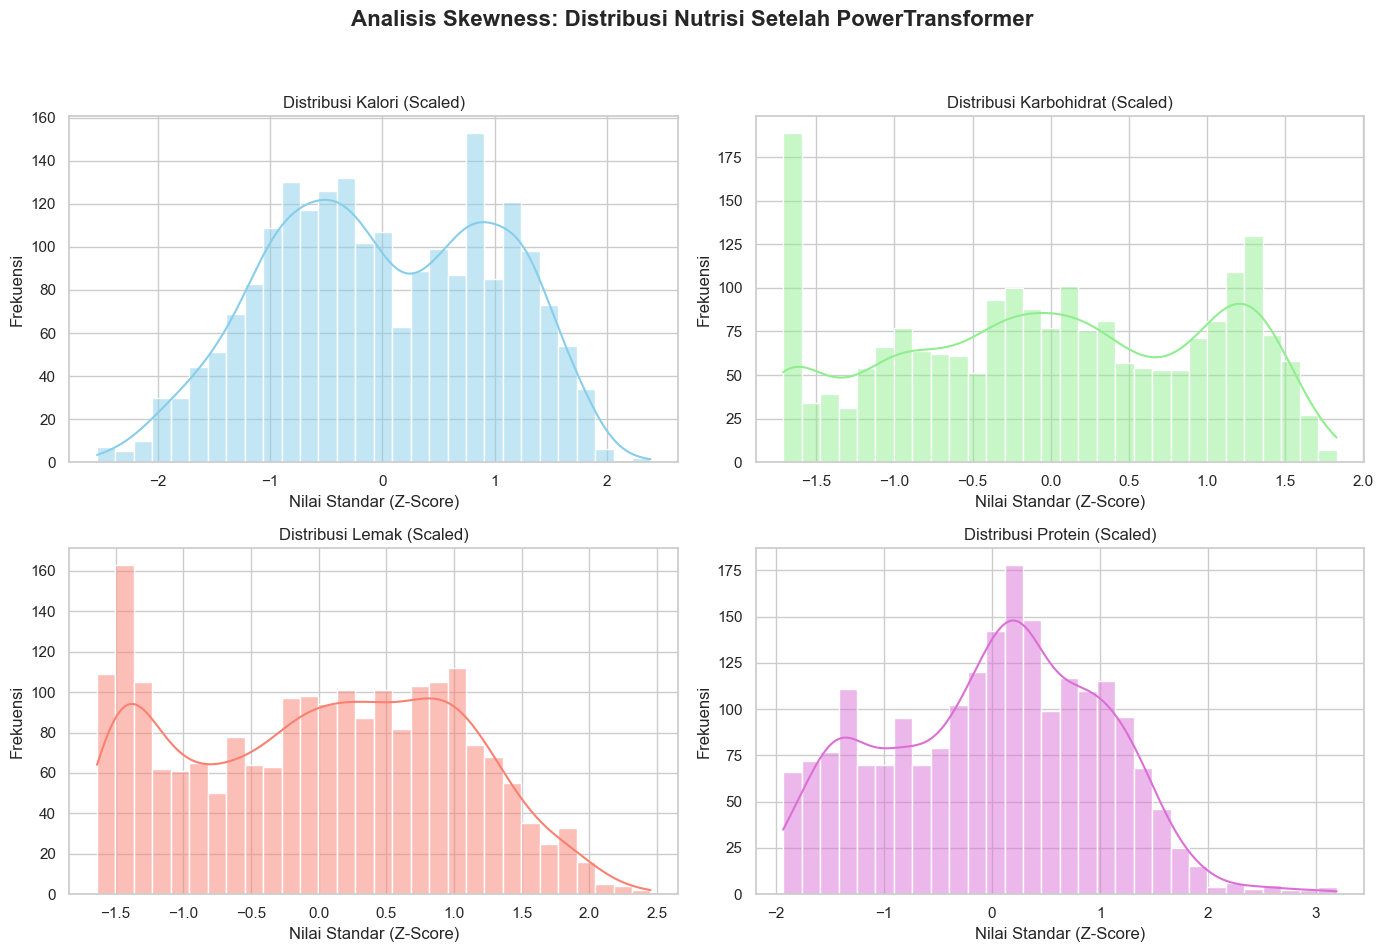

Nilai Skewness Setelah Transformasi:
- Kalori (kkal)_scaled: -0.0746
- Karbohidrat (g)_scaled: -0.1368
- Lemak (g)_scaled: -0.0162
- Protein (g)_scaled: -0.0492


In [32]:
sns.set_theme(style="whitegrid")

# Menggunakan kolom hasil transformasi untuk mengecek efektivitas scaling
# 1. Distribusi Kalori dan Makronutrien yang SUDAH DI-SCALED
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Grafik Kiri Atas: Distribusi Kalori Scaled
sns.histplot(df['Kalori (kkal)_scaled'], bins=30, kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribusi Kalori (Scaled)', fontsize=12)
axes[0, 0].set_xlabel('Nilai Standar (Z-Score)')
axes[0, 0].set_ylabel('Frekuensi')

# Grafik Kanan Atas: Distribusi Karbohidrat Scaled
sns.histplot(df['Karbohidrat (g)_scaled'], bins=30, kde=True, color='lightgreen', ax=axes[0, 1])
axes[0, 1].set_title('Distribusi Karbohidrat (Scaled)', fontsize=12)
axes[0, 1].set_xlabel('Nilai Standar (Z-Score)')
axes[0, 1].set_ylabel('Frekuensi')

# Grafik Kiri Bawah: Distribusi Lemak Scaled
sns.histplot(df['Lemak (g)_scaled'], bins=30, kde=True, color='salmon', ax=axes[1, 0])
axes[1, 0].set_title('Distribusi Lemak (Scaled)', fontsize=12)
axes[1, 0].set_xlabel('Nilai Standar (Z-Score)')
axes[1, 0].set_ylabel('Frekuensi')

# Grafik Kanan Bawah: Distribusi Protein Scaled
sns.histplot(df['Protein (g)_scaled'], bins=30, kde=True, color='orchid', ax=axes[1, 1])
axes[1, 1].set_title('Distribusi Protein (Scaled)', fontsize=12)
axes[1, 1].set_xlabel('Nilai Standar (Z-Score)')
axes[1, 1].set_ylabel('Frekuensi')

plt.suptitle('Analisis Skewness: Distribusi Nutrisi Setelah PowerTransformer', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Menampilkan nilai skewness terbaru
print("Nilai Skewness Setelah Transformasi:")
for col in ['Kalori (kkal)_scaled', 'Karbohidrat (g)_scaled', 'Lemak (g)_scaled', 'Protein (g)_scaled']:
    print(f"- {col}: {df[col].skew():.4f}")

1. Distribusi Mendekati Normal (Bell Curve): Sebelum transformasi, data nutrisi biasanya sangat miring (skewed) karena banyak makanan rendah kalori dan sedikit yang sangat tinggi. Sekarang, keempat grafik menunjukkan bentuk simetris yang lebih rapi (mendekati distribusi Normal/Gaussian).
2. Nilai Skewness Menuju Nol: Nilai skewness yang tercetak di bawah grafik (antara -0.13 hingga -0.01) menunjukkan bahwa data sudah hampir tidak miring lagi. Secara teknis, nilai di antara -0.5 dan 0.5 dianggap sangat baik dan 'aman' untuk algoritma Machine Learning.
3. Standardisasi (Z-Score): Sumbu X kini berada di kisaran angka kecil (sekitar -3 hingga 3). Ini disebut Z-Score, di mana angka 0 adalah rata-rata. Hal ini memastikan tidak ada satu nutrisi pun yang mendominasi model hanya karena angka aslinya besar (misalnya kalori vs protein).
4. Kesiapan Model AI: Dengan distribusi yang sudah normal dan skala yang seragam, model AI akan jauh lebih stabil, lebih cepat konvergen (belajar), dan tidak mudah terkecoh oleh nilai-nilai ekstrem.